In [1]:
import pandas as pd

df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_statistical_analysis/block_with_categorical_clustered.parquet")
df.head()

,encounter_block,age,sex_category,race_category,ethnicity_category,language,insurance,admission_source,bmi,charlson_comorbidity_index,...,extubated_at_pt,imv_to_discharge_hours,imv_to_death_hours,yellow_to_discharge_hours,icu_los_days,icu_readmission,icu_N,discharge_category,is_dead_hosp,is_dead_30
0,97,77,Female,Black or African American,Non-Hispanic,English,Medicare,Observation,26.370238,2.0,...,False,217.250000,217.25,213.250000,9.171817,False,1.0,Expired,True,True
1,104,57,Female,White,Non-Hispanic,English,Medicare,Surgery,38.865674,6.0,...,<NA>,119.500000,NaN,101.500000,1.314352,False,1.0,Home,False,False
2,118,56,Male,None,None,English,Medicaid,Observation,21.417354,1.0,...,<NA>,352.266667,NaN,343.266667,2.907257,False,1.0,Home,False,False
3,141,81,Female,White,Non-Hispanic,English,Medicare,Emergency/Urgent,19.066667,2.0,...,<NA>,236.433333,NaN,224.433333,12.014028,True,4.0,Rehabilitation,False,False
4,143,81,Female,White,Non-Hispanic,English,Medicare,Emergency/Urgent,NaN,2.0,...,<NA>,262.266667,NaN,245.266667,10.977222,True,3.0,Other,False,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32009 entries, 0 to 32195
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   encounter_block             32009 non-null  int64  
 1   age                         32009 non-null  int64  
 2   sex_category                32009 non-null  object 
 3   race_category               26759 non-null  object 
 4   ethnicity_category          25791 non-null  object 
 5   language                    31819 non-null  object 
 6   insurance                   32009 non-null  object 
 7   admission_source            32009 non-null  object 
 8   bmi                         25706 non-null  float64
 9   charlson_comorbidity_index  31996 non-null  float64
 10  adm_to_imv_hours            32009 non-null  float64
 11  ICU_type                    31985 non-null  object 
 12  mean_heart_rate_0_24h       32008 non-null  float64
 13  mean_map_0_24h              32005 no

In [2]:
df["pressor_24h"] = df["pressor_24h"].astype(int)
df["paralytics_24h"] = df["paralytics_24h"].astype(int)
df["pt_pre24_or_post48_Yellow"] = df["pt_pre24_or_post48_Yellow"].astype(int)

In [3]:
df.to_csv('block_with_categorical_clustered.csv', index=False)

## CIF Figure

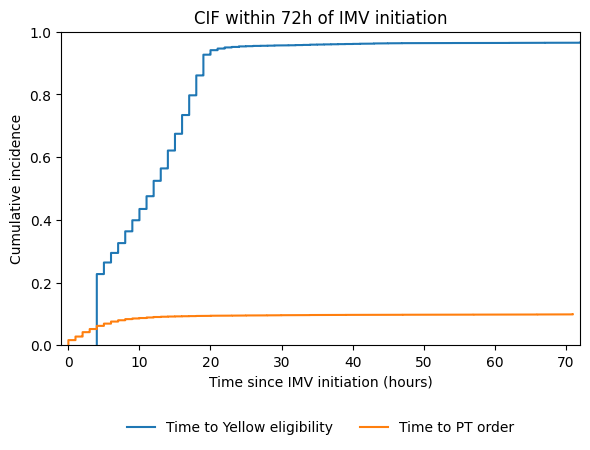

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_cif(ax, series, label, color=None, x_cap=72):
    s = pd.to_numeric(series, errors="coerce") 
    n_total = len(s)
    n_missing = int(s.isna().sum())

    s_valid = s.dropna()
    s_valid = s_valid[(s_valid >= 0) & (s_valid <= x_cap)]
    n_valid = len(s_valid)

    if n_valid > 0:
        x = np.sort(s_valid.values)
        y = np.arange(1, n_valid + 1) / n_total
        ax.step(x, y, where="post", label=label,
                #label=f"{label}  (n={n_valid}, missing={n_missing} [{n_missing/n_total:.1%}])",
                color=color)

fig1, ax1 = plt.subplots(figsize=(6, 5))

plot_cif(ax1, df["yellow_time_eligibility"], "Time to Yellow eligibility", color="tab:blue")
plot_cif(ax1, df["Time_first_PT_new"], "Time to PT order", color="tab:orange")

ax1.set_title("CIF within 72h of IMV initiation")
ax1.set_xlabel("Time since IMV initiation (hours)")
ax1.set_ylabel("Cumulative incidence")
ax1.set_xlim(-1, 72)
ax1.set_ylim(0, 1)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2, frameon=False)
fig1.tight_layout(rect=[0, 0.05, 1, 1])
fig1.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_statistical_analysis/cif_yellow_pt.png", dpi=300)
plt.show()

## Logistic Regression 1

In [25]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model1 = smf.glm(
    formula=(
        "pt_pre24_or_post48_Yellow ~ age + bmi + charlson_comorbidity_index + "
        "mean_heart_rate_0_24h + mean_map_0_24h + mean_fio2_0_24h + mean_peep_0_24h + sofa_total + "
        "min_RASS_0_24h + pressor_24h + paralytics_24h + "
        "C(sex_category) + C(race_category) + C(ethnicity_category) + "
        "C(language) + C(insurance) + C(ICU_type)"
    ),
    data=df,
    family=sm.families.Binomial()
).fit()

print(model1.summary())

                     Generalized Linear Model Regression Results                     
Dep. Variable:     pt_pre24_or_post48_Yellow   No. Observations:                18353
Model:                                   GLM   Df Residuals:                    18329
Model Family:                       Binomial   Df Model:                           23
Link Function:                         Logit   Scale:                          1.0000
Method:                                 IRLS   Log-Likelihood:                -7728.4
Date:                       Tue, 21 Oct 2025   Deviance:                       15457.
Time:                               13:26:23   Pearson chi2:                 1.85e+04
No. Iterations:                            6   Pseudo R-squ. (CS):            0.05410
Covariance Type:                   nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

In [30]:
import numpy as np

or1 = np.exp(model1.params)
ci1 = np.exp(model1.conf_int())
print(or1)
print(ci1)

Intercept                                0.190842
C(sex_category)[T.Male]                  1.037058
C(race_category)[T.Other]                1.097479
C(race_category)[T.White]                1.074746
C(ethnicity_category)[T.Non-Hispanic]    1.056862
C(language)[T.Other]                     1.016688
C(language)[T.Spanish]                   1.043604
C(insurance)[T.Medicare]                 1.036776
C(insurance)[T.None/Other]               1.092117
C(insurance)[T.Private]                  1.043659
C(ICU_type)[T.Medical ICU]               0.224144
C(ICU_type)[T.Other]                     1.058144
C(ICU_type)[T.Surgical ICU]              0.475686
age                                      1.004345
bmi                                      1.002168
charlson_comorbidity_index               0.971594
mean_heart_rate_0_24h                    0.997880
mean_map_0_24h                           1.000480
mean_fio2_0_24h                          0.723918
mean_peep_0_24h                          0.961408


## Logistic Regression 2
Covariates: no min_RASS_0_24h, add coma_0_24h

In [33]:
model2 = smf.glm(
    formula=(
        "pt_pre24_or_post48_Yellow ~ age + bmi + charlson_comorbidity_index + "
        "mean_heart_rate_0_24h + mean_map_0_24h + mean_fio2_0_24h + mean_peep_0_24h + sofa_total + "
        "coma_0_24h + pressor_24h + paralytics_24h + "
        "C(sex_category) + C(race_category) + C(ethnicity_category) + "
        "C(language) + C(insurance) + C(ICU_type)"
    ),
    data=df,
    family=sm.families.Binomial()
).fit()

print(model2.summary())

                     Generalized Linear Model Regression Results                     
Dep. Variable:     pt_pre24_or_post48_Yellow   No. Observations:                20532
Model:                                   GLM   Df Residuals:                    20508
Model Family:                       Binomial   Df Model:                           23
Link Function:                         Logit   Scale:                          1.0000
Method:                                 IRLS   Log-Likelihood:                -8598.8
Date:                       Tue, 21 Oct 2025   Deviance:                       17198.
Time:                               13:34:08   Pearson chi2:                 2.06e+04
No. Iterations:                            6   Pseudo R-squ. (CS):            0.05770
Covariance Type:                   nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

In [31]:
or2 = np.exp(model2.params)
ci2 = np.exp(model2.conf_int())
print(or2)
print(ci2)

Intercept                                0.251808
C(sex_category)[T.Male]                  1.035739
C(race_category)[T.Other]                1.096388
C(race_category)[T.White]                1.056603
C(ethnicity_category)[T.Non-Hispanic]    1.011602
C(language)[T.Other]                     1.049864
C(language)[T.Spanish]                   0.986583
C(insurance)[T.Medicare]                 1.041714
C(insurance)[T.None/Other]               1.107123
C(insurance)[T.Private]                  1.067923
C(ICU_type)[T.Medical ICU]               0.193888
C(ICU_type)[T.Other]                     0.954124
C(ICU_type)[T.Surgical ICU]              0.424162
age                                      1.003952
bmi                                      1.003546
charlson_comorbidity_index               0.974758
mean_heart_rate_0_24h                    0.998738
mean_map_0_24h                           1.000425
mean_fio2_0_24h                          0.725438
mean_peep_0_24h                          0.970060


## Logistic Regression 3
Covariate: yellow_0_24h only

In [29]:
model3 = smf.glm(
    formula=("pt_pre24_or_post48_Yellow ~ yellow_0_24h"),
    data=df,
    family=sm.families.Binomial()
).fit()

print(model3.summary())

                     Generalized Linear Model Regression Results                     
Dep. Variable:     pt_pre24_or_post48_Yellow   No. Observations:                32009
Model:                                   GLM   Df Residuals:                    32007
Model Family:                       Binomial   Df Model:                            1
Link Function:                         Logit   Scale:                          1.0000
Method:                                 IRLS   Log-Likelihood:                -13329.
Date:                       Tue, 21 Oct 2025   Deviance:                       26659.
Time:                               13:30:51   Pearson chi2:                 3.20e+04
No. Iterations:                            4   Pseudo R-squ. (CS):          7.622e-05
Covariance Type:                   nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

In [32]:
or3 = np.exp(model3.params)
ci3 = np.exp(model3.conf_int())
print(or3)
print(ci3)

Intercept       0.181148
yellow_0_24h    0.991058
dtype: float64
                     0         1
Intercept     0.167974  0.195355
yellow_0_24h  0.979823  1.002423


In [ ]:
## Logistic Regression 4

In [34]:
model4 = smf.glm(
    formula=(
        "pt_pre24_or_post48_Yellow ~ age + bmi + charlson_comorbidity_index + "
        "mean_heart_rate_0_24h + mean_map_0_24h + mean_fio2_0_24h + mean_peep_0_24h + sofa_total + "
        "coma_0_24h + pressor_24h + paralytics_24h + yellow_0_24h + "
        "C(sex_category) + C(race_category) + C(ethnicity_category) + "
        "C(language) + C(insurance) + C(ICU_type)"
    ),
    data=df,
    family=sm.families.Binomial()
).fit()

print(model4.summary())

                     Generalized Linear Model Regression Results                     
Dep. Variable:     pt_pre24_or_post48_Yellow   No. Observations:                20532
Model:                                   GLM   Df Residuals:                    20507
Model Family:                       Binomial   Df Model:                           24
Link Function:                         Logit   Scale:                          1.0000
Method:                                 IRLS   Log-Likelihood:                -8598.8
Date:                       Tue, 21 Oct 2025   Deviance:                       17198.
Time:                               13:34:21   Pearson chi2:                 2.06e+04
No. Iterations:                            6   Pseudo R-squ. (CS):            0.05771
Covariance Type:                   nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

In [35]:
or4 = np.exp(model4.params)
ci4 = np.exp(model4.conf_int())
print(or4)
print(ci4)

Intercept                                0.246846
C(sex_category)[T.Male]                  1.035094
C(race_category)[T.Other]                1.097017
C(race_category)[T.White]                1.057355
C(ethnicity_category)[T.Non-Hispanic]    1.011026
C(language)[T.Other]                     1.049654
C(language)[T.Spanish]                   0.986063
C(insurance)[T.Medicare]                 1.041511
C(insurance)[T.None/Other]               1.107103
C(insurance)[T.Private]                  1.067890
C(ICU_type)[T.Medical ICU]               0.193691
C(ICU_type)[T.Other]                     0.952476
C(ICU_type)[T.Surgical ICU]              0.423313
age                                      1.003984
bmi                                      1.003518
charlson_comorbidity_index               0.974778
mean_heart_rate_0_24h                    0.998754
mean_map_0_24h                           1.000418
mean_fio2_0_24h                          0.729514
mean_peep_0_24h                          0.970156
